In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np

## Unsupervized learning

* Is a type of Machine Learning
* Looks for patterns in data
* No pre-existing labels and minimum human intervention


## Clustering

* Is a type of unsupervized learning
* Groups data with similar properties in groups called clusters
* Can be done with differnet algorithms:
  - K-means
  - Gaussian Mixture Model
  - DBSCAN
  - Mean Shift
  - Aglomerative Clustering



---------------------------------
1️⃣ K-Means Clustering
---------------------------------

**Overview**

K-Means is one of the simplest and most popular clustering algorithms. It partitions the data into K clusters, trying to minimize the variance within each cluster. Each cluster is represented by its centroid (mean of points in the cluster). K-Means works best when clusters are roughly spherical and equally sized.

**Algorithm Steps**

1.   Initialize K cluster centroids (randomly or using K-Means++).
2.   Assign each point to the nearest centroid (based on Euclidean distance).
3.   Update centroids by computing the mean of all points assigned to each cluster.
4.   Repeat steps 2–3 until convergence (centroids don’t change significantly or max iterations reached).

Mathematical Formulation

The objective is to minimize the within-cluster sum of squares (WCSS):

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$

Where:

$C_k$ = set of points in cluster $k$

$\mu_k$ = centroid of cluster $k$

$\|\cdot\|$ = Euclidean norm

![alt text](https://miro.medium.com/max/480/1*KrcZK0xYgTa4qFrVr0fO2w.gif)

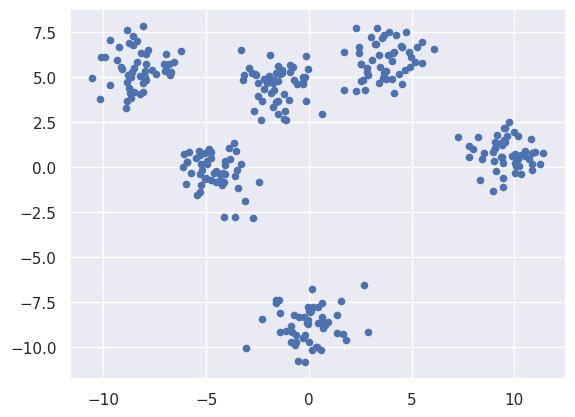

In [ ]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=6, cluster_std=1.0, random_state=7)
plt.scatter(X[:, 0], X[:, 1], s=20);

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

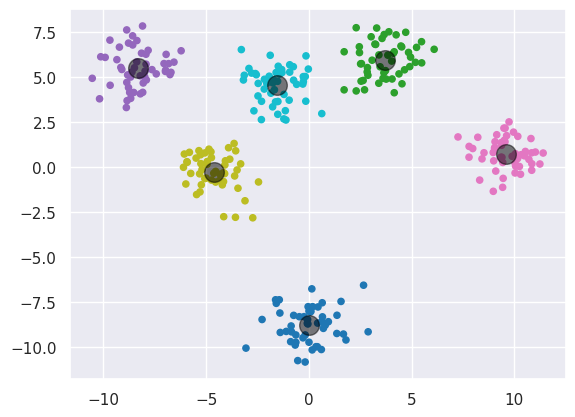

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='tab10')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

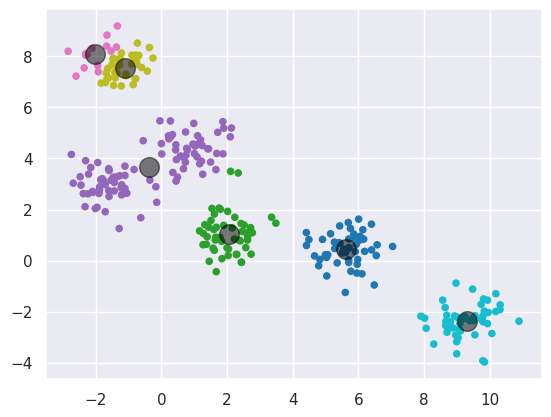

In [ ]:
from sklearn.metrics import pairwise_distances_argmin
from sklearn.datasets import make_blobs

def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # Compute new centers
        new_centers = np.array([X[labels == j].mean(0) for j in range(n_clusters)])

        # Check for convergence
        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return centers, labels


X, y_true = make_blobs(n_samples=300, centers=6, cluster_std=0.60, random_state=0)

centers, labels = find_clusters(X, 6)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='tab10')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

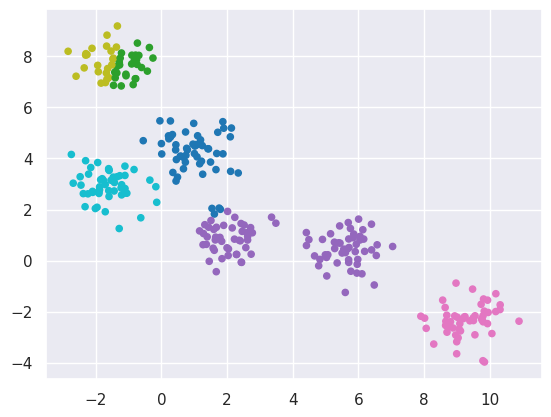

In [ ]:
centers, labels = find_clusters(X, 6, rseed=15)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=20, cmap='tab10');

**Strengths**

* Fast and simple.

* Works well on well-separated, spherical clusters.

* Easy to interpret centroids.

**Limitations**

* Sensitive to initialization (K-Means++ helps).

* Sensitive to outliers (they shift centroids).

* Assumes spherical clusters → fails on elongated or overlapping clusters.

* Must specify K in advance.

--------------
Metrics
-------------

**Homogenity** - A clustering result satisfies homogeneity if all of its clusters contain only data points which are members of a single class.

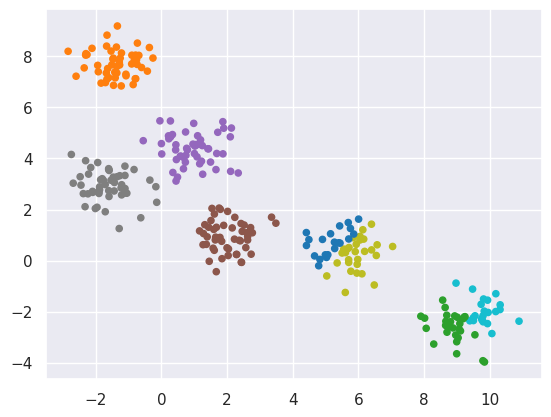

In [ ]:
kmeans = KMeans(n_clusters=8)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='tab10')

In [ ]:
from sklearn.metrics.cluster import homogeneity_score
homogeneity_score(y_true, y_kmeans)

np.float64(1.0000000000000002)

**Completeness** - A clustering result satisfies completeness if all the data points that are members of a given class are elements of the same cluster.

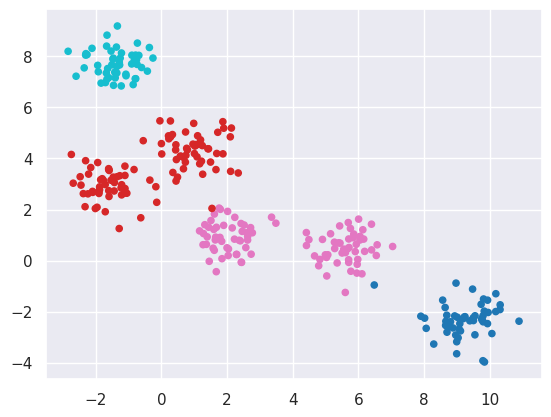

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='tab10')

In [ ]:
from sklearn.metrics.cluster import completeness_score
completeness_score(y_true, y_kmeans)

np.float64(0.9754630162837801)

The **V-measure** is the harmonic mean between homogeneity and completeness

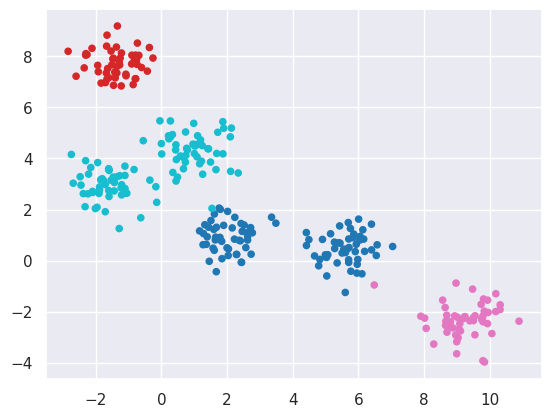

In [ ]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=20, cmap='tab10')

In [ ]:
homogeneity_score(y_true, y_kmeans)

np.float64(0.7250835377395332)

In [ ]:
completeness_score(y_true, y_kmeans)

np.float64(0.9754630162837801)

In [ ]:
from sklearn.metrics.cluster import v_measure_score
v_measure_score(y_true, y_kmeans)

np.float64(0.8318410020681182)

-------------------------
K-means - MNIST Dataset
---------------------------

In [ ]:
# 8 x 8 images
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# Intensity from 0 to 16
digits.data.max()

np.float64(16.0)

In [ ]:
# 10 digits
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

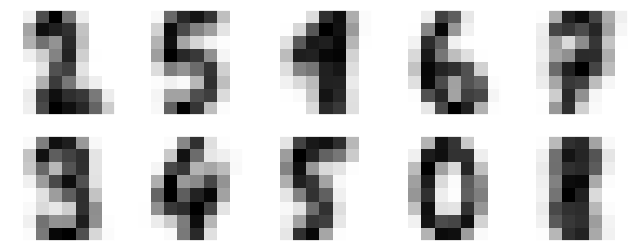

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [ ]:
from sklearn.metrics.cluster import v_measure_score
v_measure_score(digits.target, clusters)

np.float64(0.7305876278345286)

--------
TSNE
--------

Sometimes, for bettter visualization and clustering, dimentionality reduction methods are employed. One of them is TSNE.

In [ ]:
from sklearn.manifold import TSNE

# Project the data: this step will take several seconds
tsne = TSNE(n_components=2, init='random', random_state=0)
tsne_proj = tsne.fit_transform(digits.data)

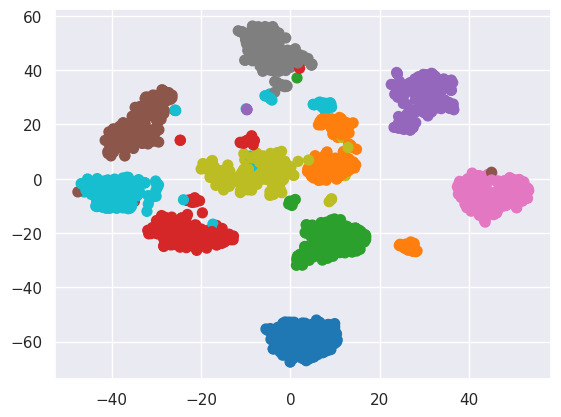

In [ ]:
plt.scatter(tsne_proj[:, 0], tsne_proj[:, 1], c=digits.target, s=50, cmap='tab10')

In [ ]:
# Compute the clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(tsne_proj)

In [ ]:
# Permute the labels
from scipy import stats
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = stats.mode(digits.target[mask])[0]

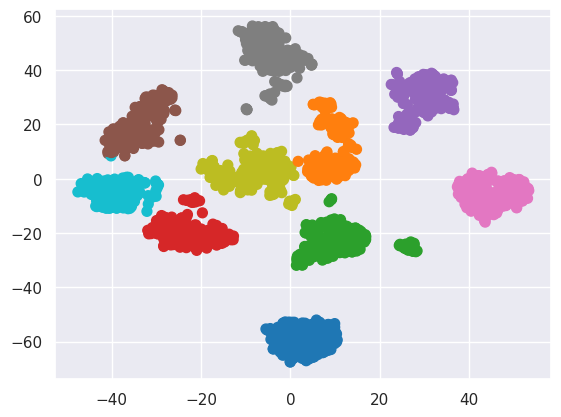

In [ ]:
plt.scatter(tsne_proj[:, 0], tsne_proj[:, 1], c=labels, s=50, cmap='tab10')

In [ ]:
from sklearn.metrics.cluster import v_measure_score
v_measure_score(digits.target, labels)

np.float64(0.9037924165591291)

---------------------------------
PCA
---------------------------------

Another dimentionality reduction method is PCA

In [ ]:
from sklearn.decomposition import PCA
pca_proj = PCA(n_components=2).fit_transform(digits.data)

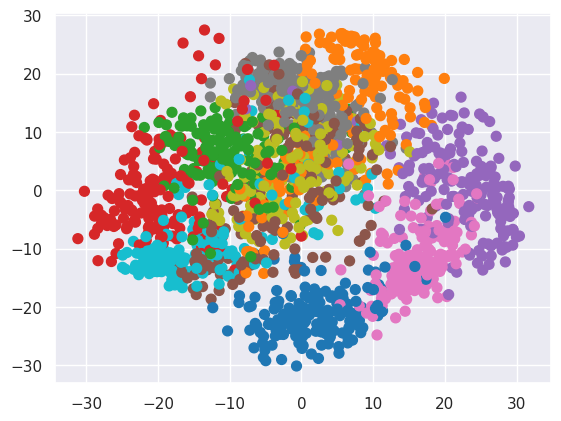

In [ ]:
plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=digits.target, s=50, cmap='tab10')

In [ ]:
# Compute the clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(pca_proj)

In [ ]:
# Permute the labels
from scipy import stats
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = stats.mode(digits.target[mask])[0]

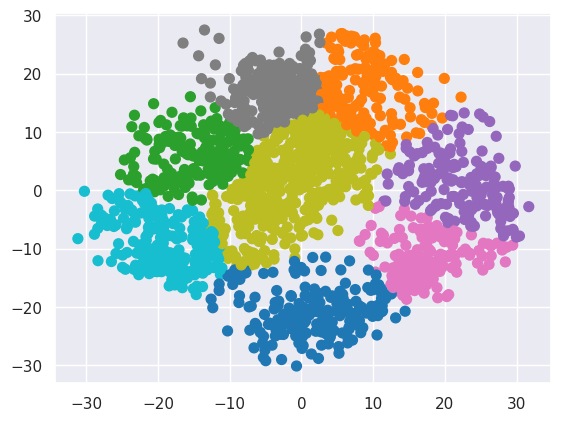

In [ ]:
plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=labels, s=50, cmap='tab10')

In [ ]:
from sklearn.metrics.cluster import v_measure_score
v_measure_score(digits.target, labels)

np.float64(0.515106950201059)

-------------
Question 1
------------

Why is there such a difference between PCA and TSNE? Does it mean that one of them is extraordinary and the other one useless? Not quite... but to understand them better we need to look at their differences. Check this out:

https://towardsdatascience.com/pca-vs-tsne-el-cl%C3%A1sico-9948181a5f87

Now state your opinion on why there is such a discrepancy on the given Dataset:

*----------Your answer here-------------*

----------------------------
2️⃣ Gaussian Mixture Model (GMM)
------------------------------

**Gaussian Mixture Models** are probabilistic clustering algorithms. Unlike K-Means, which assigns each point to a single cluster, GMM assigns a probability of belonging to each cluster.

* Each cluster is modeled as a multivariate Gaussian distribution.

* Useful for overlapping or elliptical clusters.

**Algorithm Steps**

1. Initialize the parameters for K Gaussian components (means, covariances, mixing coefficients).

2. Expectation (E-step): Compute the probability that each point belongs to each cluster.

3. Maximization (M-step): Update the parameters to maximize the likelihood of the data given the probabilities.

4. Repeat E-step and M-step until convergence (log-likelihood stabilizes or max iterations reached).

**Mathematical Formulation**

The probability density of a Gaussian mixture is:

$$
p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Where:

$\pi_k$ = mixing coefficient for cluster $k$ $(0 < \pi_k < 1, sum of \pi_k = 1)$

$\mu_k$ = mean of cluster $k$

$\Sigma_k$ = covariance matrix of cluster $k$

$\mathcal{N}(x \mid \mu_k, \Sigma_k)$ = multivariate Gaussian density

The **log-likelihood** of the data is:

$$
\log L = \sum_{i=1}^{N} \log \left( \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right)
$$

Hyperparameters

* n_components: number of Gaussian clusters K.

* covariance_type: type of covariance (full, tied, diag, spherical)

    * full → each cluster has its own covariance matrix (most flexible)

    * diag → diagonal covariance (less flexible, faster)

* max_iter: maximum number of EM iterations.

* tol: convergence threshold for log-likelihood.

* init_params: method to initialize parameters (kmeans or random).

In [ ]:
from sklearn import mixture

X, y_true = make_blobs(n_samples=300, centers=6, cluster_std=1.0, random_state=7)
cv_type = 'full'
n_components = 6
gmm = mixture.GaussianMixture(n_components=n_components, covariance_type=cv_type)
gmm.fit(X)

GaussianMixture(n_components=6)

In [ ]:
y_mixture = gmm.predict(X)

In [ ]:
y_mixture

array([0, 2, 3, 0, 5, 4, 2, 5, 1, 1, 5, 3, 0, 4, 4, 5, 1, 3, 3, 5, 1, 2,
       5, 0, 5, 1, 4, 5, 0, 1, 2, 1, 3, 0, 5, 5, 4, 3, 4, 3, 2, 2, 4, 4,
       2, 4, 0, 4, 2, 2, 1, 1, 5, 0, 5, 2, 5, 3, 3, 5, 0, 4, 1, 0, 0, 0,
       2, 5, 0, 1, 4, 2, 3, 2, 2, 3, 5, 4, 4, 4, 2, 5, 4, 2, 5, 5, 5, 3,
       1, 0, 5, 2, 4, 3, 3, 2, 0, 0, 1, 2, 4, 2, 3, 1, 3, 0, 2, 2, 2, 1,
       4, 1, 0, 1, 0, 4, 0, 0, 1, 4, 1, 0, 0, 5, 0, 2, 3, 3, 4, 3, 1, 4,
       5, 0, 3, 5, 3, 5, 5, 5, 0, 0, 4, 5, 3, 3, 4, 5, 3, 0, 0, 4, 1, 3,
       1, 4, 4, 0, 4, 3, 4, 3, 5, 5, 1, 0, 2, 0, 0, 2, 3, 3, 0, 0, 0, 5,
       4, 2, 2, 2, 5, 3, 1, 0, 0, 1, 2, 4, 4, 5, 5, 0, 3, 4, 1, 1, 1, 1,
       1, 2, 5, 5, 1, 5, 2, 4, 2, 3, 5, 1, 3, 1, 1, 2, 2, 4, 5, 1, 2, 5,
       2, 5, 1, 5, 3, 3, 2, 2, 3, 3, 3, 1, 1, 3, 1, 3, 1, 0, 3, 4, 2, 3,
       0, 2, 1, 0, 2, 1, 5, 4, 5, 3, 3, 3, 1, 0, 4, 2, 1, 1, 5, 0, 0, 3,
       4, 4, 0, 4, 1, 2, 2, 5, 1, 4, 3, 4, 1, 1, 2, 0, 1, 3, 5, 3, 2, 4,
       3, 4, 5, 4, 2, 4, 0, 2, 0, 4, 4, 5, 2, 0])

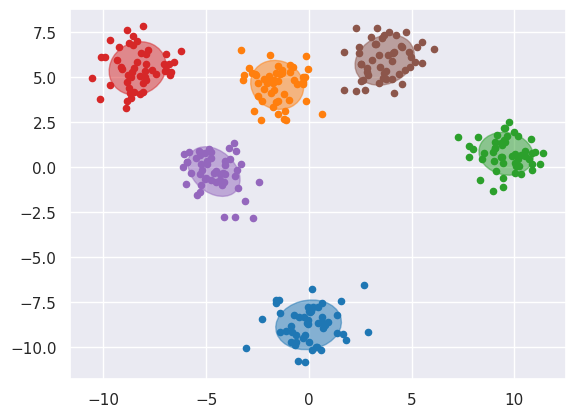

In [ ]:
import matplotlib as mpl
from scipy import linalg
fig = plt.gca()

cmap = mpl.colormaps['tab10']
for i, (mean, cov) in enumerate(zip(gmm.means_, gmm.covariances_)):
    v, w = linalg.eigh(cov)
    color = cmap(i / 10)   # evenly spaced colors
    fig.scatter(X[y_mixture == i, 0], X[y_mixture == i, 1], s=20, color=color)
    angle = np.arctan2(w[0][1], w[0][0])
    angle = 180. * angle / np.pi
    v = 2. * np.sqrt(2.) * np.sqrt(v)
    ell = mpl.patches.Ellipse(mean, v[0], v[1], angle=180. + angle, color=color)
    ell.set_alpha(.5)
    fig.add_artist(ell)


In [ ]:
np.random.seed(42)
transformation = np.random.rand(2, 2)
X_elip = np.dot(X, transformation)
gmm = mixture.GaussianMixture(n_components=n_components, covariance_type=cv_type)
gmm.fit(X_elip)
y_mixture = gmm.predict(X_elip)

/tmp/ipython-input-2421496142.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab10')


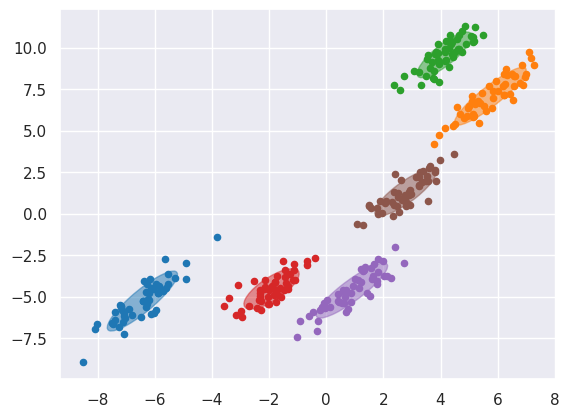

In [ ]:
fig = plt.gca()
cmap = mpl.cm.get_cmap('tab10')
for i, (mean, cov) in enumerate(zip(gmm.means_, gmm.covariances_)):
    v, w = linalg.eigh(cov)
    color = color=cmap(i/10)
    fig.scatter(X_elip[y_mixture==i, 0], X_elip[y_mixture==i, 1], s=20, color=color);
    angle = np.arctan2(w[0][1], w[0][0])
    angle = 180. * angle / np.pi
    v = 2. * np.sqrt(2.) * np.sqrt(v)
    ell = mpl.patches.Ellipse(mean, v[0], v[1], angle=180. + angle, color=color)
    ell.set_alpha(.5)
    fig.add_artist(ell)

**Strengths**

* Handles elliptical and overlapping clusters better than K-Means.

* Probabilistic assignments allow soft clustering (each point has membership probabilities).

* Flexible with different covariance types.

**Limitations**

* Sensitive to initialization (can get stuck in local maxima).

* Requires number of components (K) to be specified.

* Can be computationally expensive for high-dimensional data.

* Assumes clusters follow Gaussian distributions, which may not hold in all datasets.

-------------------------------
3️⃣ DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
-------------------------------

**<h2>Overview</h2>**

DBSCAN is a **density-based clustering algorithm**. Unlike K-Means or GMM, it does not assume a specific cluster shape and can find **arbitrary-shaped clusters**.

* Clusters are defined as **dense regions of points** separated by sparser regions.

* Points that do not belong to any dense region are labeled as **noise**.

**<h2>Algorithm Steps</h2>**

1. For each point, count the number of points within a radius eps.

2. Classify points as:

    * Core points: at least min_samples neighbors within eps.

    * Border points: fewer than min_samples neighbors but connected to a core point.

    * Noise points: not a core or border point.

3. Connect core points that are reachable within eps to form clusters.

4. Assign border points to the nearest core cluster.

Mathematical Formulation

Let $N_\epsilon(x_i)$ be the set of points within radius $eps$ of $x_i$:

$$
N_\epsilon(x_i) = \{ x_j \mid \|x_i - x_j\| \leq \epsilon \}
$$

* A **core** point satisfies:

$$
|N_\epsilon(x_i)| \geq {min\_samples}
$$

* A point $x_i$ is directly density-reachable from a core point $x_j$ if:

$$
x_j \in N_\epsilon(x_i) \text{ and } |N_\epsilon(x_i)| \geq {min\_samples}
$$

* Clusters are formed by connecting all density-reachable points.


![alt text](https://miro.medium.com/max/675/1*tc8UF-h0nQqUfLC8-0uInQ.gif)





**<h2>Hyperparameters</h2>**

* eps: the radius to search for neighboring points.

    * Smaller → more clusters, potentially more noise.

    * Larger → fewer clusters, may merge distinct groups.

* min\_samples: minimum number of points to form a dense region.

    * Higher → stricter definition of core points.

* metric: distance metric (default Euclidean).

In [ ]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

In [ ]:
def make_smile(n_samples, radius=0.4, noise_st = 0.08):
    x_coord = np.expand_dims(radius * np.cos(np.linspace(np.pi, 2*np.pi, n_samples)), axis=1)
    y_coord = np.expand_dims(radius * np.sin(np.linspace(np.pi, 2*np.pi, n_samples)), axis=1)
    X = np.hstack((x_coord, y_coord))
    noise = (np.random.random_sample((n_samples, 2)) * 2 - 1) * noise_st
    return X + noise

In [ ]:
X, y = make_circles(n_samples=400, factor=0.999, noise=.03)
X1, y1 = make_blobs(n_samples=100, centers=[[-0.4,0.4], [0.4,0.4]], cluster_std=0.06)
X2 = make_smile(100)
X3 = np.random.random_sample((50, 2)) * 2 - 1
X = np.concatenate([X, X1, X2, X3], axis=0)

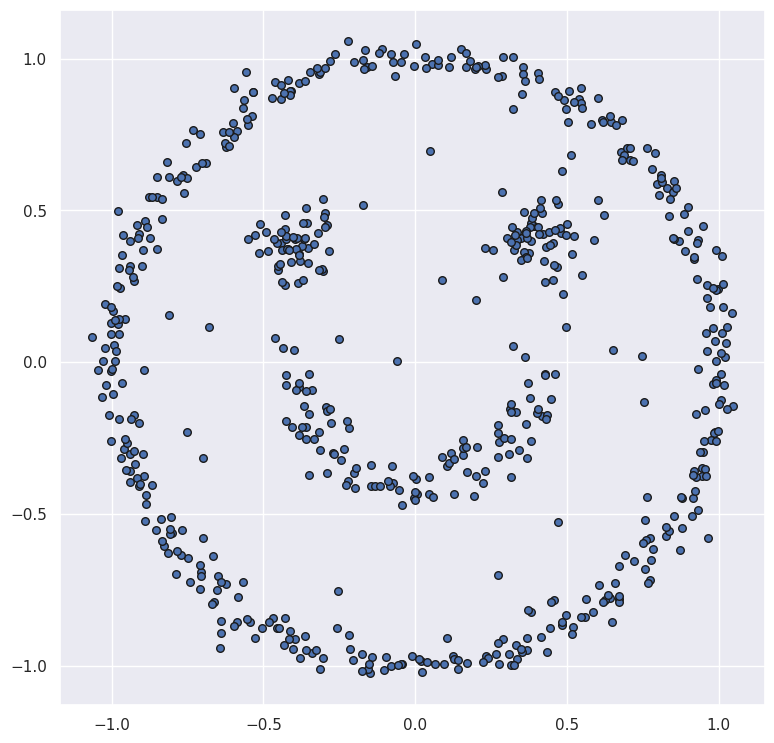

In [ ]:
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')

plt.scatter(X[:, 0], X[:, 1], s=30, edgecolor='k')

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
db = DBSCAN(eps=0.12, min_samples=10).fit(X)
labels = db.labels_

In [ ]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [ ]:
import matplotlib as mpl
cmap = mpl.cm.get_cmap('tab20')

/tmp/ipython-input-2808836070.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20')


In [ ]:
colors = [0] * labels.size
sizes = [0] * labels.size
for i in range(labels.size):
    if labels[i] == -1:
        colors[i] = 'black'
        sizes[i] = 20
    else:
        colors[i] = cmap(labels[i]/10)
        sizes[i] = 50

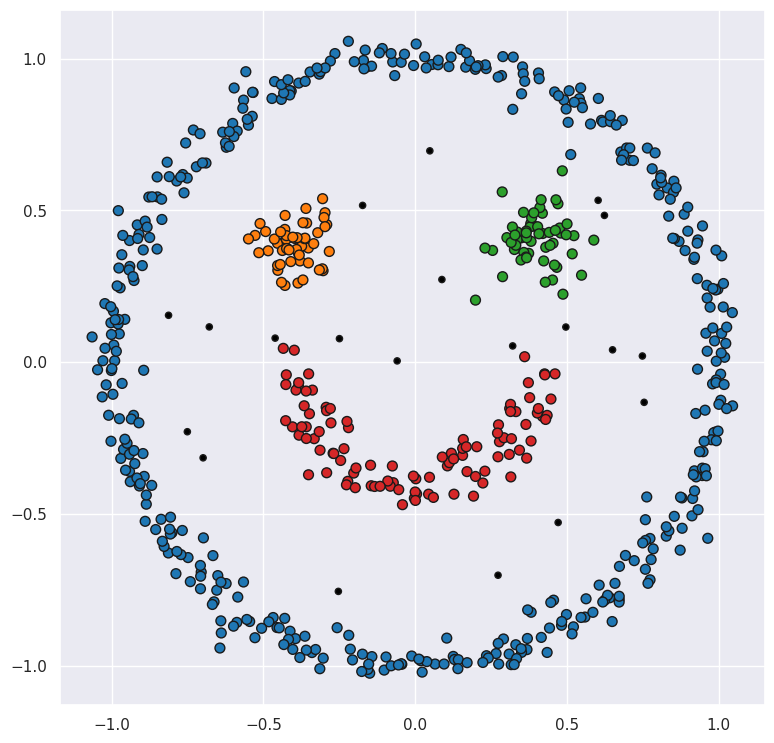

In [ ]:
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')

plt.scatter(X[:, 0], X[:, 1], c=colors, s=sizes, edgecolor='k')

In [ ]:
db = DBSCAN(eps=0.1, min_samples=10).fit(X)
labels = db.labels_

In [ ]:
colors = [0] * labels.size
sizes = [0] * labels.size
for i in range(labels.size):
    if labels[i] == -1:
        colors[i] = 'black'
        sizes[i] = 20
    else:
        colors[i] = cmap(labels[i]/10)
        sizes[i] = 50

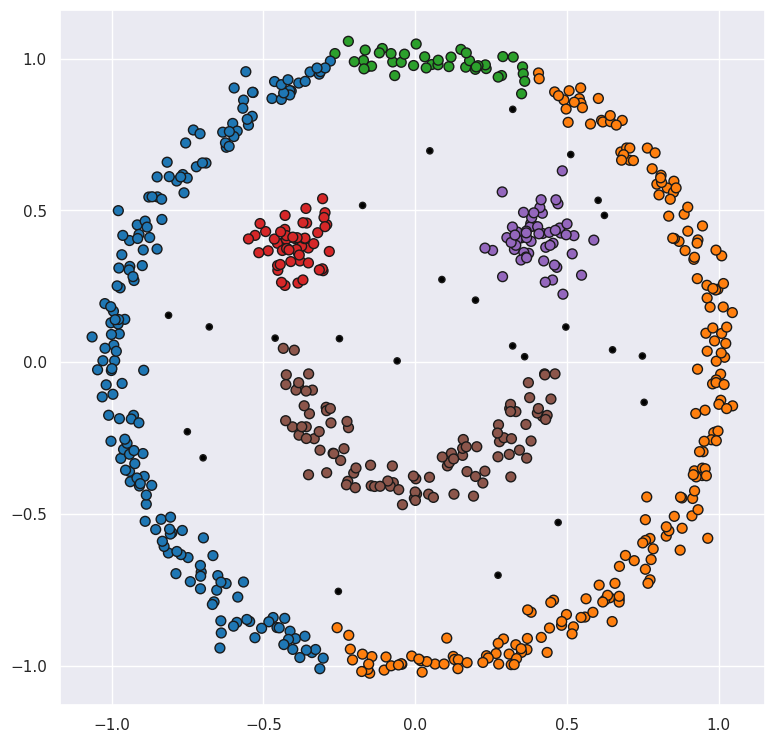

In [ ]:
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')

plt.scatter(X[:, 0], X[:, 1], c=colors, s=sizes, edgecolor='k')

In [ ]:
db = DBSCAN(eps=0.2, min_samples=10).fit(X)
labels = db.labels_

In [ ]:
colors = [0] * labels.size
sizes = [0] * labels.size
for i in range(labels.size):
    if labels[i] == -1:
        colors[i] = 'black'
        sizes[i] = 20
    else:
        colors[i] = cmap(labels[i]/10)
        sizes[i] = 50

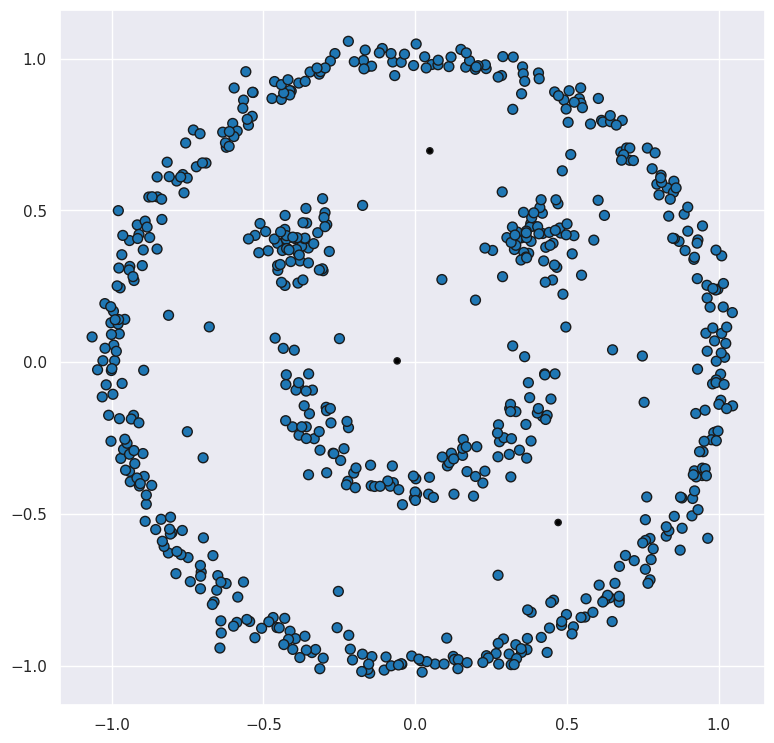

In [ ]:
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')

plt.scatter(X[:, 0], X[:, 1], c=colors, s=sizes, edgecolor='k')

**<h2>Strengths</h2>**

* Can find **arbitrary-shaped clusters**.

* **Robust to outliers** — noise points are labeled separately.

* Does not require specifying the number of clusters in advance.

**<h2>Limitations</h2>**

* Sensitive to eps and min_samples; choosing them correctly can be tricky.

* Struggles with clusters of **very different densities**.

* Computationally expensive on **very large datasets**.

--------------------------------------------
4️⃣ Mean Shift Clustering
--------------------------------------------

**<h2>Overview</h2>**

Mean Shift is a **centroid-based clustering** algorithm that does not require specifying the number of clusters in advance.

* It works by iteratively shifting data points toward the mode **(highest density region)** of the data distribution.

* Clusters are defined as basins of attraction around these modes.

**<h2>Algorithm Steps</h2>**

1. Place a window (kernel) around each data point.

2. Compute the mean of points inside the window.

3. Shift the window center to this mean.

4. Repeat until convergence (window centers stabilize).

5. Points whose windows converge to the same mode belong to the same cluster.

**<h2>Mathematical Formulation</h2>**

The **update rule** for the kernel window is:

$$
m(x) = \frac{\sum_{x_i \in N(x)} K(x_i - x) \, x_i}{\sum_{x_i \in N(x)} K(x_i - x)}
$$

Where:

* $N(x)$ = set of points within the kernel window centered at $x$

* $K$ = kernel function (commonly a Gaussian kernel)

* $m(x)$ = mean shift vector (new center position)

The algorithm iteratively updates $x → m(x)$ until convergence.


**<h2>Hyperparameters</h2>**

* bandwidth: the radius of the kernel window.

    * Small bandwidth → many small clusters.

    * Large bandwidth → fewer, larger clusters.

* max_iter: maximum iterations allowed.

* cluster_all: whether to assign all points to clusters (default True).

![alt text](https://miro.medium.com/max/324/1*bkFlVrrm4HACGfUzeBnErw.gif)       ![alt text](https://miro.medium.com/max/432/1*vyz94J_76dsVToaa4VG1Zg.gif)

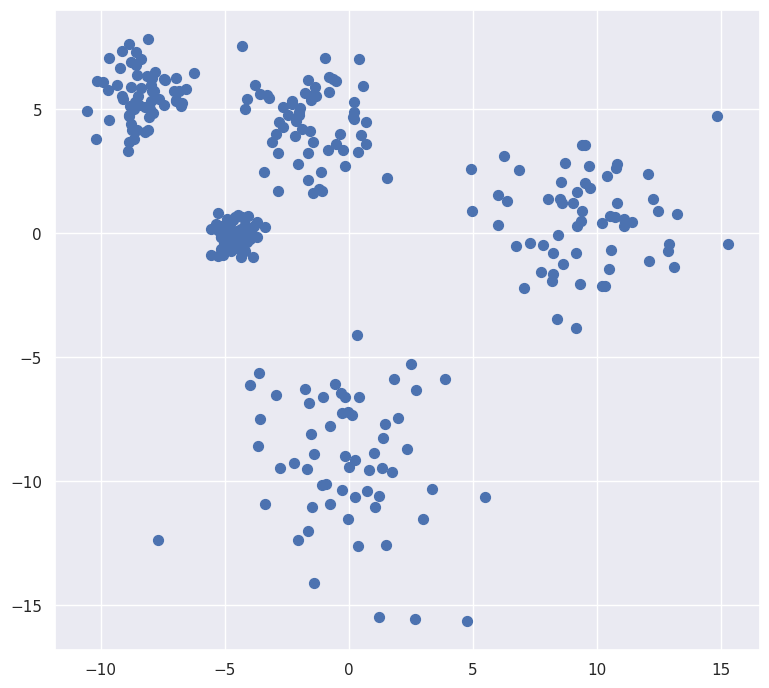

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=[1.0,1.5,2.0,2.5,0.5], random_state=7)
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
bandwidth = estimate_bandwidth(X, quantile=0.12)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

MeanShift(bandwidth=np.float64(2.792364728454837), bin_seeding=True)

In [ ]:
labels = ms.labels_
cluster_centers = ms.cluster_centers_

In [ ]:
import matplotlib as mpl
cmap = mpl.cm.get_cmap('tab20')

/tmp/ipython-input-2808836070.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20')


In [ ]:
colors = [0] * labels.size
for i in range(labels.size):
    colors[i] = cmap(labels[i]/10)

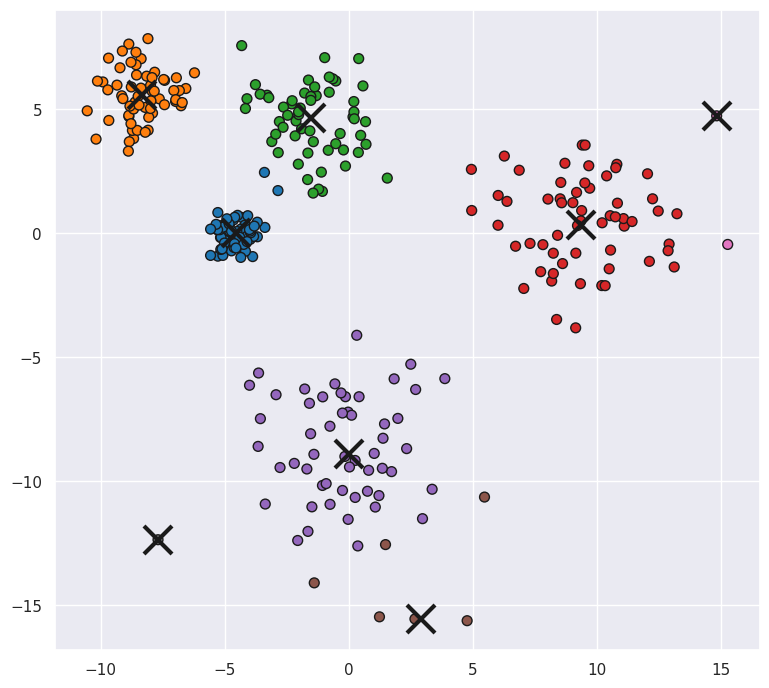

In [ ]:
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, edgecolor='k')
for cluster_center in cluster_centers:
    plt.plot(cluster_center[0], cluster_center[1], 'x', markeredgecolor='k', markersize=20, mew=3)

In [ ]:
bandwidth = estimate_bandwidth(X, quantile=0.3)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

MeanShift(bandwidth=np.float64(7.793221087742626), bin_seeding=True)

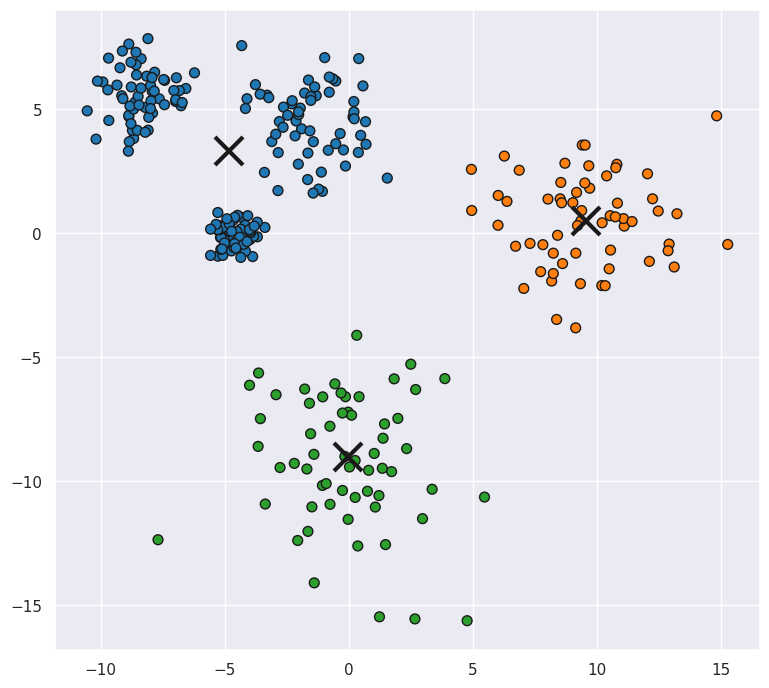

In [ ]:
labels = ms.labels_
cluster_centers = ms.cluster_centers_
colors = [0] * labels.size
for i in range(labels.size):
    colors[i] = cmap(labels[i]/10)
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, edgecolor='k')
for cluster_center in cluster_centers:
    plt.plot(cluster_center[0], cluster_center[1], 'x', markeredgecolor='k', markersize=20, mew=3)

In [ ]:
bandwidth = estimate_bandwidth(X, quantile=0.05)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

MeanShift(bandwidth=np.float64(1.670483144932674), bin_seeding=True)

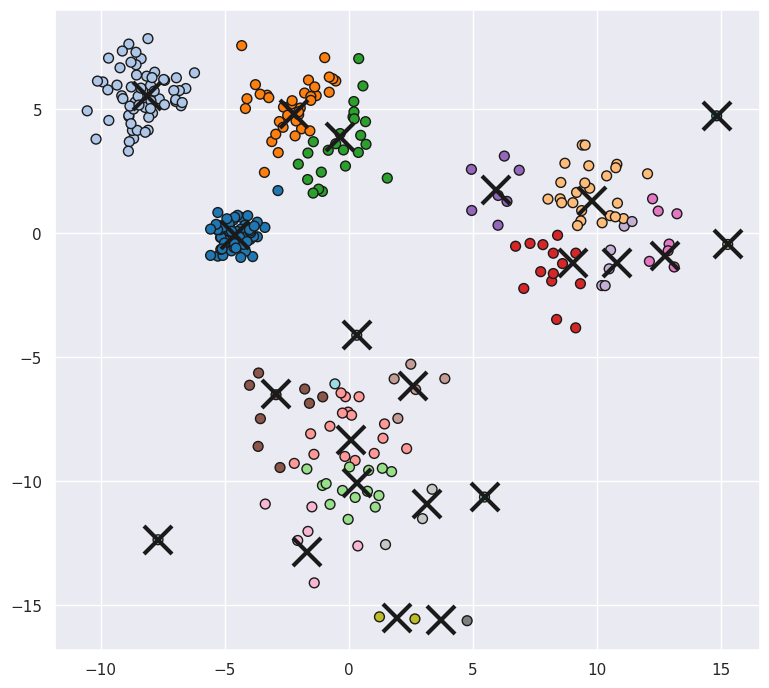

In [ ]:
labels = ms.labels_
cluster_centers = ms.cluster_centers_
colors = [0] * labels.size
for i in range(labels.size):
    colors[i] = cmap(labels[i]/20)
plt.figure(figsize=(20, 20))
plt.subplot(2, 2, 1, aspect='equal')
plt.scatter(X[:, 0], X[:, 1], c=colors, s=50, edgecolor='k')
for cluster_center in cluster_centers:
    plt.plot(cluster_center[0], cluster_center[1], 'x', markeredgecolor='k', markersize=20, mew=3)

**<h2>Strengths</h2>**

* Does not require pre-specifying the number of clusters.

* Can find **arbitrary-shaped clusters**.

* Naturally handles noise by grouping points toward density peaks.

**<h2>Limitations</h2>**

* Sensitive to the **bandwidth parameter**.

* Computationally expensive on large datasets.

* Struggles with very high-dimensional data.

----------------------------------------
5️⃣ Agglomerative Clustering
----------------------------------------

**<h2>Overview</h2>**

Agglomerative Clustering is a **hierarchical clustering algorithm** that builds clusters by repeatedly merging the two closest clusters.

* It starts with each point as its own cluster.

* At each step, the two most similar clusters are merged.

* This continues until the desired number of clusters is reached.

The process is often visualized using a **dendrogram**, which shows the merging order.

**<h2>Algorithm Steps</h2>**

!. Assign each point to its own cluster.

2. Compute pairwise distances between all clusters.

3. Merge the two closest clusters based on the chosen linkage criterion.

4. Repeat until the number of clusters equals n_clusters.

**<h2>Mathematical Formulation</h2>**

Let clusters $C_i$ and $C_j$ be candidates for merging. The distance between them depends on the linkage criterion:

 * **Single linkage** (minimum distance):

 $$
 d(C_i, C_j) = \min_{x \in C_i, \, y \in C_j} \|x - y\|
 $$

 * **Complete linkage** (maximum distance):

 $$
 d(C_i, C_j) = \max_{x \in C_i, \, y \in C_j} \|x - y\|
 $$

 * **Average linkage** (mean distance):

 $$
 d(C_i, C_j) = \frac{1}{|C_i| \cdot |C_j|} \sum_{x \in C_i} \sum_{y \in C_j} \|x - y\|
 $$

**<h2>Hyperparameters</h2>**

* n_clusters: number of clusters to form.

* linkage: method for calculating inter-cluster distance (single, complete, average, ward).

* affinity: distance metric (default is Euclidean for most linkages).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation, rc
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [ ]:
import matplotlib as mpl
cmap = mpl.cm.get_cmap('tab20')

/tmp/ipython-input-2808836070.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab20')


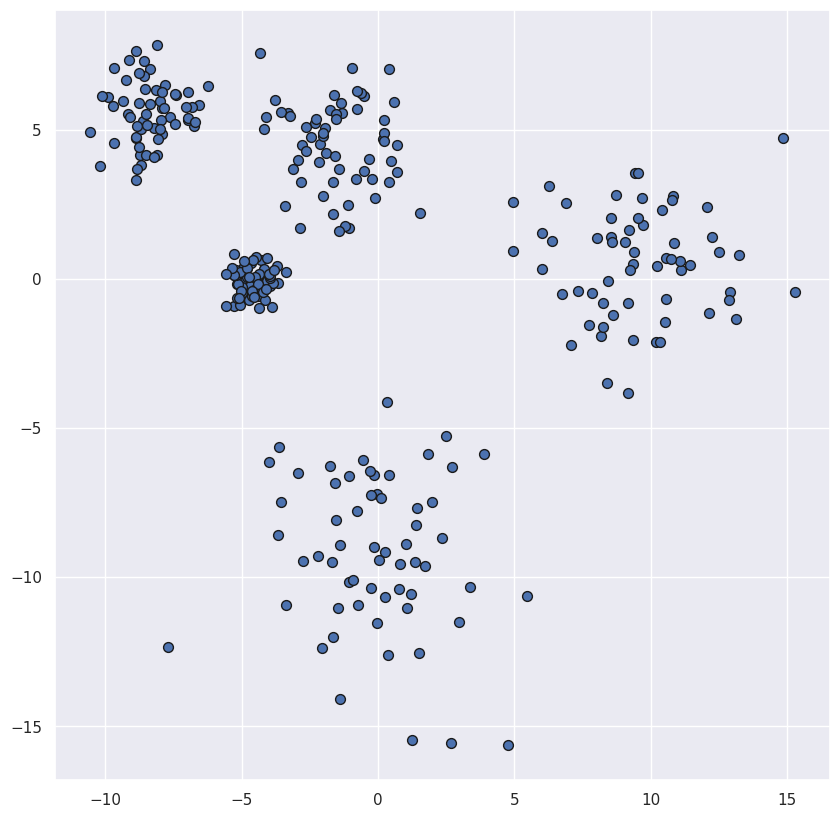

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
fig.set_facecolor('white')
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=[1.0,1.5,2.0,2.5,0.5], random_state=7)
scat = ax.scatter(X[:,0], X[:,1], s=50, edgecolor='k')

In [ ]:
def get_labels(linkage, X, n_clusters, prev_labels=None):
    aggcluster = AgglomerativeClustering(linkage=linkage, n_clusters=n_clusters)
    aggcluster.fit(X)
    labels = aggcluster.labels_
    new_labels = labels.copy()

    if prev_labels is not None:
        for i in range(10):
            ids = np.arange(len(labels))[labels == i]
            for j in range(10):
                prev_ids = np.arange(len(labels))[prev_labels == j]
                if np.array_equal(ids, prev_ids):
                    new_labels[ids] = j
                elif set(prev_ids).issubset(ids) and prev_ids.size * 2 >= ids.size:
                    new_labels[ids] = j

    return new_labels

In [ ]:
def get_colors(labels):
    colors = [0] * labels.size
    for i in range(labels.size):
        colors[i] = cmap(labels[i]/10)
    return colors

In [ ]:
def animate(i, linkage):
    global labels
    prev_labels = labels
    labels = get_labels(linkage=linkage, X=X, n_clusters=10-i, prev_labels=prev_labels)
    color = get_colors(labels)
    scat.set_color(color)

In [ ]:
linkage = 'ward'
labels = None
anim = FuncAnimation(fig, animate, fargs=(linkage,), interval=2000, frames=10)
HTML(anim.to_html5_video())

In [ ]:
linkage = 'complete'
labels = None
anim = FuncAnimation(fig, animate, fargs=(linkage,), interval=2000, frames=10)
HTML(anim.to_html5_video())

**<h2>Strengths</h2>**

* Produces a hierarchical structure (dendrogram).

* Can capture non-convex cluster shapes (depending on linkage).

* No need to pre-specify the number of clusters if using a dendrogram cut. (you still need to specify the distance threshold for the cut though)

**<h2>Limitations</h2>**

* Computationally expensive for large datasets ($𝑂(𝑛^3)$ in naive form).

* Sensitive to noise and outliers.

* Different linkage choices can lead to very different results.

-------------
Assignment
-------------

1) Use various clustering methods on the data from the [mall customers datasets](https://www.kaggle.com/datasets/shwetabh123/mall-customers).
Find interesting correlations and try to explain the reasons with appropiate interpretations. Try to find at least some correlations that seem counterintuitive at first. Use dimentionality reduction techniques for better clustering and visualization.

2) Bonus task - Same requirements for the credit card data from the [credit card dataset](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata). This is a harder dataset, so you might need to dig deeper for insights.
